In [19]:
import pandas as pd

In [20]:
df_cat1 = pd.read_csv("../data/PNR_1z/raw/PNR_1z_catalog.csv",index_col='ts').sort_index()
df_cat1.index = pd.to_datetime(df_cat1.index)
df_cat1_nsta  =  pd.read_csv("../data/PNR_1z/raw/PNR-1z_ms_catalogue_nsta.csv", skiprows=[1])
for col in ["UTC Time", "Job Time"]:
    df_cat1_nsta[col] = pd.to_datetime(df_cat1_nsta[col], format="%d:%m:%y:%H:%M:%S")
df_cat1_nsta = df_cat1_nsta.set_index("UTC Time").sort_index()

In [21]:
df_cat2 = pd.read_csv("../data/PNR_2/raw/PNR_2_catalog.csv",index_col='ts').sort_index()
df_cat2.index = pd.to_datetime(df_cat2.index)
df_cat2_nsta  =  pd.read_csv("../data/PNR_2/raw/PNR-2_ms_catalogue_nsta.csv", skiprows=[1])
for col in ["UTC Time", "Job Time"]:
    df_cat2_nsta[col] = pd.to_datetime(df_cat2_nsta[col], format="%d:%m:%y:%H:%M:%S")
df_cat2_nsta = df_cat2_nsta.set_index("UTC Time").sort_index()


In [22]:
def compare_indices(a, b, name_a='A', name_b='B', show=True):
    set_a, set_b = set(a.tolist()), set(b.tolist())
    only_a = set_a - set_b
    only_b = set_b - set_a
    if show:
        if not only_a and not only_b:
            print("The two lists are identical.")
        else:
            print(f"Only in {name_a}: {len(only_a)}")
            print(f"Only in {name_b}: {len(only_b)}")
    return {"only_in_" + name_a: list(only_a), "only_in_" + name_b: list(only_b)}

In [23]:
cmp_res1 = compare_indices(df_cat1.index, df_cat1_nsta.index, name_a='df_cat1', name_b='df_cat1_nsta')
cmp_res2 = compare_indices(df_cat2.index, df_cat2_nsta.index, name_a='df_cat2', name_b='df_cat2_nsta')

Only in df_cat1: 881
Only in df_cat1_nsta: 1282
Only in df_cat2: 1839
Only in df_cat2_nsta: 33


In [24]:
df_cat2_nsta['SP_MAGNITUDE'].max(),df_cat2['Magnitude'].max()

(np.float64(1.145), np.float64(2.7889))

In [25]:
df_cat2_nsta.keys()

Index(['Job Time', 'Sleeve', 'Frequency', 'QC_LOC_X', 'QC_LOC_Y', 'QC_LOC_Z',
       'SP_MAGNITUDE', 'MS_SNR'],
      dtype='object')

In [26]:
df_cat2_nsta.loc[(df_cat2_nsta.index>=pd.to_datetime("2019-08-26 07:29:00"))&(df_cat2_nsta.index<=pd.to_datetime("2019-08-26 07:31:00"))]


,Job Time,Sleeve,Frequency,QC_LOC_X,QC_LOC_Y,QC_LOC_Z,SP_MAGNITUDE,MS_SNR
UTC Time,,,,,,,,
2019-08-26 07:29:46,2019-08-26 08:29:46,7,2,336084.35,432705.82,-2021.52,-2.109,3.181
2019-08-26 07:30:58,2019-08-26 08:30:58,7,6,336110.67,432537.08,-1967.66,-0.793,4.237
2019-08-26 07:30:59,2019-08-26 08:30:59,7,6,336235.72,432439.22,-2041.88,-1.071,2.840
2019-08-26 07:30:59,2019-08-26 08:30:59,7,6,336081.08,432535.05,-1955.59,-0.640,6.306


In [27]:
df_cat2_nsta['SP_MAGNITUDE'].max()

np.float64(1.145)

In [28]:
df_cat2[df_cat2['Magnitude']==df_cat2['Magnitude'].max()]

,Latitude,Longitude,Magnitude,Depth
ts,,,,
2019-08-26 07:30:47,432500,336150,2.7889,-2060.0


## Processing injection sequences

In [29]:
import os
import glob
import re
import pandas as pd

In [30]:
df_inj1 = pd.read_csv("../data/PNR_1z/raw/PNR-1z_injection_rates.csv",index_col='ts').sort_index()
df_inj1.index = pd.to_datetime(df_inj1.index)
df_inj2 = pd.read_csv("../data/PNR_2/raw/PNR-2_injection_rates.csv",index_col='ts').sort_index()
df_inj2.index = pd.to_datetime(df_inj2.index)   

In [31]:
def add_utc_column(df):
    df['JobTime'] = pd.to_datetime(df['JobTime'], format="%d:%m:%y:%H:%M:%S")
    df['JobTime'] = df['JobTime'].dt.tz_localize('Europe/London', ambiguous='infer')
    df['UTCTime'] = df['JobTime'].dt.tz_convert('UTC')
    df['UTCTime'] = df['UTCTime'].dt.tz_localize(None)
    df['UTCTime'] = pd.to_datetime(df['UTCTime'])
    return df

def process_pumping_df(df,stage):
    df = add_utc_column(df)
    df = df.dropna(how='all')
    return df

In [32]:
df = pd.read_csv("../data/PNR_1z/raw/Pumping Data/008-PNR1z-15.10.18-Sleeve1-DFIT.csv", skiprows=[1])
df = add_utc_column(df)
df = df.dropna(how='all')
match =  re.search(r'Sleeve(\d+)', "../data/PNR_1z/raw/Pumping Data/008-PNR1z-15.10.18-Sleeve1-DFIT.csv")
stage = match.group(1) if match else "unknown"
print(f"Stage: {stage}")

Stage: 1


In [33]:
def process_pumping_data(csv_files, pattern=r'Sleeve(\d+)', verbose=False):
    df_list = []
    for file in csv_files:
        df = pd.read_csv(file, skiprows=[1]).dropna(how='all')
        df = add_utc_column(df).dropna(how='all')
        
        # Extract stage from filename
        match = re.search(pattern, file)
        stage = match.group(1) if match else "0"
        
        df['Stage'] = int(stage)
        df['INJ_RATE'] = pd.to_numeric(df['INJ_RATE'], errors='coerce')
        df = df[['UTCTime', 'Stage', 'INJ_RATE']].dropna(subset=['UTCTime'])
        
        if verbose:
            print(f"Processing Stage {stage}: {df['UTCTime'].min()} to {df['UTCTime'].max()}")
            
        df.set_index('UTCTime', inplace=True)
        # Remove duplicate indices by averaging within each file
        df.sort_index(inplace=True)
        df = df.groupby(level=0).mean()
        df_list.append(df)
    
    # Concatenate all stages and sort
    df_result = pd.concat(df_list).sort_index()
    
    # Final deduplication across files if necessary
    if df_result.index.duplicated().any():
        df_result = df_result.groupby(level=0).mean()

    if verbose:
        print(f"Total rows: {len(df_result)}")
        print(f"Duplicate indices remaining: {df_result.index.duplicated().any()}")
        
    return df_result

In [34]:
base_dir1 = "../data/PNR_1z/raw/Pumping Data"
csv_files1 = glob.glob(os.path.join(base_dir1, "*.csv"))
df_inj1_nsta = process_pumping_data(csv_files1, verbose=True)

Processing Stage 1: 2018-10-15 08:56:31 to 2018-10-16 07:22:55
Processing Stage 1: 2018-10-16 10:23:49 to 2018-10-17 07:06:59


/root/autodl-tmp/tmp/ipykernel_19312/1897218784.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=[1]).dropna(how='all')


Processing Stage 2: 2018-10-17 07:49:27 to 2018-10-18 07:16:29
Processing Stage 3: 2018-10-18 09:47:35 to 2018-10-19 07:46:25
Processing Stage 12: 2018-10-19 07:58:25 to 2018-10-20 07:09:26
Processing Stage 12: 2018-10-20 07:32:22 to 2018-10-22 07:11:28
Processing Stage 13: 2018-10-22 07:24:55 to 2018-10-23 07:47:13
Processing Stage 14: 2018-10-23 07:59:56 to 2018-10-24 07:15:01
Processing Stage 18: 2018-10-24 07:56:09 to 2018-10-25 07:12:13
Processing Stage 22: 2018-10-25 07:39:28 to 2018-10-26 07:28:52
Processing Stage 30: 2018-10-26 07:52:19 to 2018-10-27 07:10:53
Processing Stage 31: 2018-10-27 07:26:19 to 2018-10-27 22:59:44
Processing Stage 32: 2018-10-29 08:49:15 to 2018-10-30 07:39:57
Processing Stage 41: 2018-10-30 08:17:42 to 2018-10-31 07:37:33
Processing Stage 37: 2018-10-31 08:48:59 to 2018-11-01 07:37:26
Processing Stage 38: 2018-11-02 07:59:53 to 2018-11-02 23:59:28
Processing Stage 37: 2018-12-08 07:35:21 to 2018-12-08 23:59:59
Processing Stage 37: 2018-12-10 07:37:16 t

In [36]:
base_dir2 = "../data/PNR_2/raw/Pumping Data"
csv_files2 = glob.glob(os.path.join(base_dir2, "*.csv"))
df_inj2_nsta = process_pumping_data(csv_files2)

/root/autodl-tmp/tmp/ipykernel_19312/1897218784.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=[1]).dropna(how='all')


In [37]:
df_inj1_m_nsta = df_inj1_nsta.resample('1Min').mean().interpolate()
df_inj1_m_nsta.loc[df_inj1_m_nsta['INJ_RATE'] > 20, 'INJ_RATE'] = 0
df_inj1_m_nsta.loc[df_inj1_m_nsta['INJ_RATE'] < 0, 'INJ_RATE'] = 0
df_inj2_m_nsta = df_inj2_nsta.resample('1Min').mean().interpolate()
df_inj2_m_nsta.loc[df_inj2_m_nsta['INJ_RATE'] > 20, 'INJ_RATE'] = 0
df_inj2_m_nsta.loc[df_inj2_m_nsta['INJ_RATE'] < 0, 'INJ_RATE'] = 0  

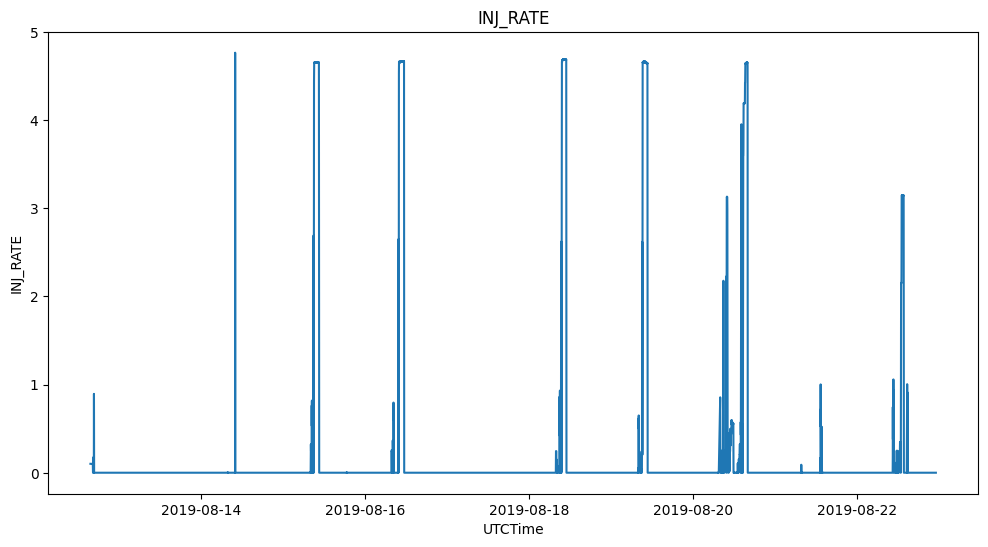

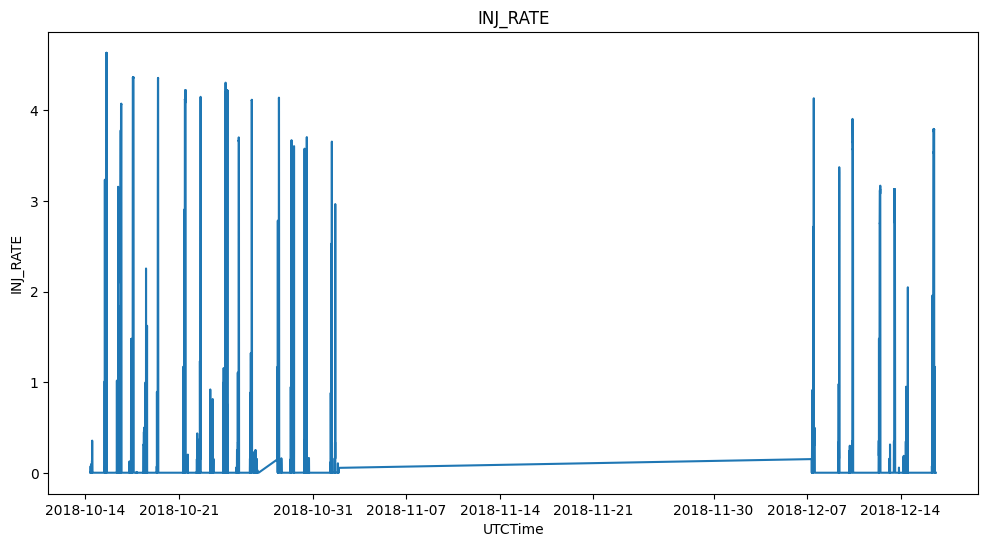

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))  
plt.plot(df_inj2_m_nsta.index, df_inj2_m_nsta['INJ_RATE'])
plt.title('INJ_RATE')
plt.xlabel('UTCTime')
plt.ylabel('INJ_RATE')
plt.show()
plt.figure(figsize=(12,6))
plt.plot(df_inj1_m_nsta.index, df_inj1_m_nsta['INJ_RATE'])
plt.title('INJ_RATE')       
plt.xlabel('UTCTime')
plt.ylabel('INJ_RATE')
plt.show()